##### Copyright 2025 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

#### Developed by AI/ML GDE [Nitin Tiwari](https://linkedin.com/in/tiwari-nitin).
* LinkedIn: [linkedin.com/in/tiwari-nitin](https://linkedin.com/in/tiwari-nitin)
* GitHub: [github.com/NSTiwari](https://github.com/NSTiwari)
* X: [@NSTiwari21](https://x.com/NSTiwari21)




This notebook covers Part 2 of the implementation for converting and quantizing the PaliGemma 2 Vision Language Model to ONNX for inference with Transformers.js.

* [Part 1]: [Convert and quantize PaliGemma 2 to ONNX.](https://github.com/NSTiwari/PaliGemma2-ONNX-Transformers.js/blob/main/Convert_PaliGemma2_to_ONNX.ipynb)

* [Part 2]: [Inference the converted model using 🤗 Transformers.js for tasks like image captioning, zero-shot object detection, OCR, and visual Q&A.](https://github.com/NSTiwari/PaliGemma2-ONNX-Transformers.js/blob/main/Inference_PaliGemma2_with_Transformers_js.ipynb)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/NSTiwari/PaliGemma2-ONNX-Transformers.js/blob/main/Inference_PaliGemma2_with_Transformers_js.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>


### Select the runtime

To complete this tutorial, you'll need to have a Colab runtime with sufficient resources to load the PaliGemma 2 model. In this case, a T4/L4 GPU would be needed to load the model weights.

1. In the upper-right of the Colab window, click the **▾ (Additional connection options)** dropdown menu.
1. Select **Change runtime type**.
1. Under **Hardware accelerator**, select **T4 or L4**.

### Step 1: Install Node.js

In [1]:
# Install Node.js
!curl -fsSL https://deb.nodesource.com/setup_20.x | sudo -E bash -
!sudo apt-get install -y nodejs

2025-02-17 14:47:12 - Installing pre-requisites
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,315 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,60

### Step 2: Setup environment
Create a new Node.js project, and configure the package.

In [2]:
!mkdir paligemma2
%cd paligemma2

# Initialize NPM project.
!npm init -y
!npm i @huggingface/transformers canvas

/content/paligemma2
Wrote to /content/paligemma2/package.json:

{
  "name": "paligemma2",
  "version": "1.0.0",
  "main": "index.js",
  "scripts": {
    "test": "echo \"Error: no test specified\" && exit 1"
  },
  "keywords": [],
  "author": "",
  "license": "ISC",
  "description": ""
}



⠙⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 115 packages, and audited 116 packages in 20s
⠴
⠴27 packages are looking for funding
⠴  run `npm fund` for details
⠴
found 0 vulnerabilities
⠴

In [119]:
%%writefile package.json

{
  "name": "paligemma2",
  "version": "1.0.0",
  "main": "index.js",
  "type": "module",
  "scripts": {
    "test": "echo \"Error: no test specified\" && exit 1"
  },
  "keywords": [],
  "author": "Nitin Tiwari",
  "license": "MIT",
  "description": "",
  "dependencies": {
    "@huggingface/transformers": "^3.1.2"
  }
}

Overwriting package.json


### Step 3: Inference with Transformers.js
Load the ONNX weights of the PaliGemma 2 model. Next, pass the input image along with the text prompt and then parse the output.

**Example prompts:**

* Object Detection: `<image>detect object-name`
* Image Captioning: `<image>caption`
* Optical Character Recognition (OCR): `<image>OCR`
* Visual Question Answering (VQA): `<image>What is the color of the person's shirt?`

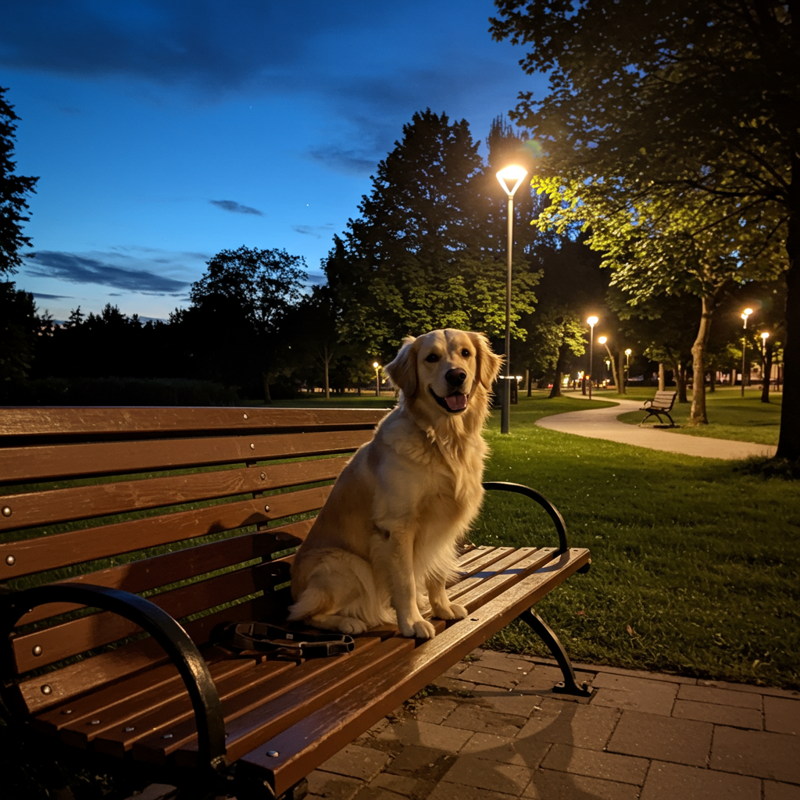

In [108]:
from PIL import Image
import requests

# Load a sample image.
image_path = "image_00.png" # @param {type: "string"}
image_path = f"/content/{image_path}"

# Prompt.
prompt = "detect dog" # @param {type: 'string'}

prompt = f"<image>{prompt}"

img = Image.open(image_path)
img

In [116]:
%%writefile index.js

import { AutoProcessor, PaliGemmaForConditionalGeneration, load_image } from "@huggingface/transformers";
import { createCanvas, loadImage } from "canvas";
import fs from "fs";

function getRandomColor() {
  const r = Math.floor(Math.random() * 256);
  const g = Math.floor(Math.random() * 256);
  const b = Math.floor(Math.random() * 256);
  return `rgb(${r},${g},${b})`;
}

// Load processor and model
const model_id = "NSTiwari/paligemma2-onnx";
const processor = await AutoProcessor.from_pretrained(model_id);
const model = await PaliGemmaForConditionalGeneration.from_pretrained(
  model_id,
  {
    dtype: {
      embed_tokens: "fp16", // or 'fp16'
      vision_encoder: "fp16", // or 'q4', 'fp16'
      decoder_model_merged: "q4", // or 'q4f16'
    },
  }
);
console.log("Model and processor loaded successfully!");

// Prepare inputs for PaliGemma 2.
const image = "/content/image_002.png"; // Path to the image.
const raw_image = await load_image(image); // Load image for PaliGemma 2.

const prompt = "<image>"; // Default prompt.

// Extract the label from the prompt <image>detect <label>.
const labelMatch = prompt.match(/detect (\w+)/);
const label = labelMatch ? labelMatch[1] : "Unknown"; // Default to "Unknown" if no label found.

// Capitalize the first letter of the label.
const capitalizedLabel = label.charAt(0).toUpperCase() + label.slice(1);

const inputs = await processor(raw_image, prompt);
console.log("Inputs prepared successfully!");

try {
  // Generate a response from the model.
  const response = await model.generate({
    ...inputs,
    max_new_tokens: 100, // Maximum number of tokens to generate.
  });

  // Extract the generated IDs from the response.
  const generatedIds = response.slice(null, [inputs.input_ids.dims[1], null]);

  // Decode the generated IDs to get the answer.
  const decodedAnswer = processor.batch_decode(generatedIds, {
    skip_special_tokens: true,
  });



  if (prompt.includes("<image>detect")) {
    // Parse the response to extract bounding box coordinates.
    const boundingBoxes = decodedAnswer[0].match(/<loc(\d+)>/g);

    if (boundingBoxes && boundingBoxes.length === 4) {
      const coordinates = boundingBoxes.map(tag => parseInt(tag.replace("<loc", "").replace(">", "")));
      const [y1, x1, y2, x2] = coordinates.map(coord => Math.floor(coord));

      // Normalize the bounding box coordinates (scale to actual image dimensions).
      const normX1 = Math.round((x1 / 1024) * raw_image.width);
      const normY1 = Math.round((y1 / 1024) * raw_image.height);
      const normX2 = Math.round((x2 / 1024) * raw_image.width);
      const normY2 = Math.round((y2 / 1024) * raw_image.height);

      // Log the normalized bounding box coordinates.
      console.log("Normalized Bounding Box:", [normX1, normY1, normX2, normY2]);

      // Load the image again using canvas for drawing.
      const canvasImage = await loadImage(image); // Use the canvas loadImage here
      const canvas = createCanvas(canvasImage.width, canvasImage.height);
      const ctx = canvas.getContext("2d");

      // Draw the original image onto the canvas.
      ctx.drawImage(canvasImage, 0, 0);


      const randomColor = getRandomColor();

      ctx.strokeStyle = randomColor;
      ctx.lineWidth = 5;
      ctx.strokeRect(normX1, normY1, normX2 - normX1, normY2 - normY1);

      const labelPadding = 10;
      const textWidth = ctx.measureText(capitalizedLabel).width;
      const labelWidth = textWidth * 2.5;
      const labelHeight = 30;
      const labelY = normY1 - labelHeight;


      ctx.fillStyle = randomColor;
      ctx.fillRect(normX1, labelY, labelWidth, labelHeight);

      ctx.fillStyle = "white";
      ctx.font = "bold 20px Arial";
      ctx.fillText(capitalizedLabel, normX1 + labelPadding, labelY + labelHeight - labelPadding);

      // Save output image.
      const outputImagePath = "/content/output.jpg";
      const buffer = canvas.toBuffer("image/jpeg");
      fs.writeFileSync(outputImagePath, buffer);

      console.log("Object detected in the image, and saved to", outputImagePath);

    }
    else {
      console.log("Bounding boxes not found for the object.");
    }

  }
  else{
  console.log(decodedAnswer[0]);
}

}

catch (error) {
  console.error("Error generating response:", error);
}

Overwriting index.js


#### Overwrite the JS code with input prompt and image

In [117]:
with open('/content/paligemma2/index.js', 'r') as file:
    js_code = file.read()

import re

# Replace the line where the prompt is defined (handles any previous prompt)
js_code = re.sub(r'const prompt = ".*";', f'const prompt = "{prompt}";', js_code)
js_code = re.sub(r'const image = ".*";', f'const image = "{image_path}";', js_code)

# Write the updated code back to index.js
with open('/content/paligemma2/index.js', 'w') as file:
    file.write(js_code)

print(f"index.js has been updated with: \nPrompt: {prompt}\nImage path: {image_path}")

index.js has been updated with: 
Prompt: <image>detect dog
Image path: /content/image_00.png


### Run application

Model and processor loaded successfully!
Inputs prepared successfully!
Normalized Bounding Box: [ 282, 327, 499, 642 ]
Object detected in the image, and saved to /content/output.jpg


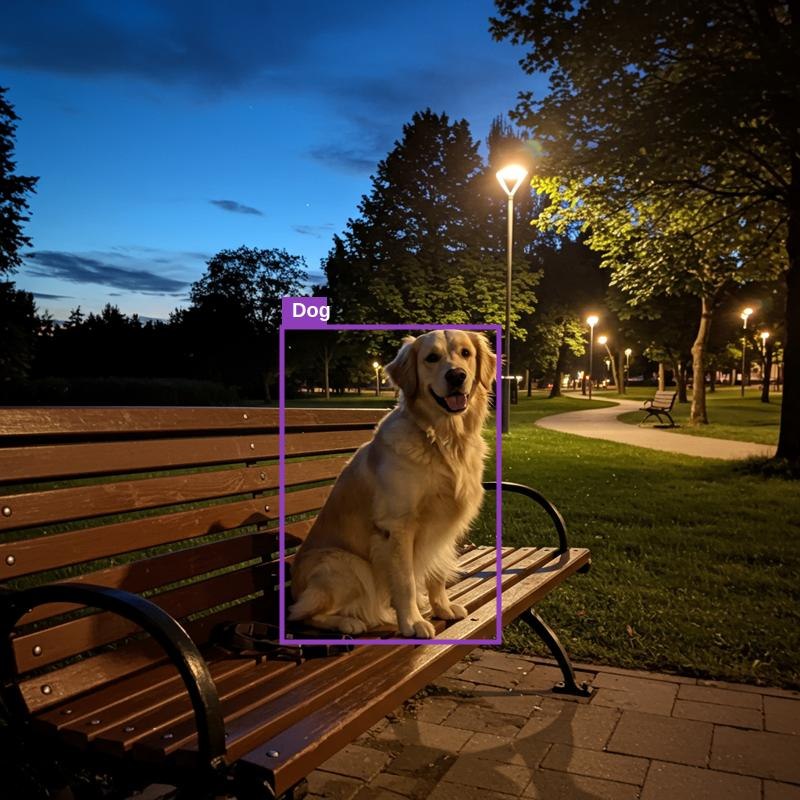

In [118]:
# Run the Node.js application.
!node index.js

if "detect" in prompt:
  output_image = Image.open("/content/output.jpg")
  display(output_image)